In [5]:
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import MACCSkeys
from rdkit.Chem.rdMolDescriptors import GetMorganFingerprintAsBitVect
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import AllChem
import numpy as np
import pandas as pd
import xgboost as xgb
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')
print(f"Размер датасета: {df_train.shape}")
print("Пример данных:")
display(df_train.head())
print(df_train.isnull().sum())

print(f"Размер  тестового датасета: {df_test.shape}")
print("Пример данных:")
display(df_test.head())
print(df_test.isnull().sum())

Размер датасета: (16328, 4)
Пример данных:


,id,SMILES1,SMILES2,result
0,0,CCC(C)n1ncn(-c2ccc(N3CCN(c4ccc(OCC5COC(Cn6cncn...,O=C(O)C=CC(=O)O,1
1,1,CCC(C)n1ncn(-c2ccc(N3CCN(c4ccc(OCC5COC(Cn6cncn...,O=C(O)CC(=O)O,0
2,2,CCC(C)n1ncn(-c2ccc(N3CCN(c4ccc(OCC5COC(Cn6cncn...,O=C(O)CCC(=O)O,1
3,3,CCC(C)n1ncn(-c2ccc(N3CCN(c4ccc(OCC5COC(Cn6cncn...,O=C(O)CC(O)C(=O)O,1
4,4,CCC(C)n1ncn(-c2ccc(N3CCN(c4ccc(OCC5COC(Cn6cncn...,O=C(O)C(O)C(O)C(=O)O,1


id         0
SMILES1    0
SMILES2    0
result     0
dtype: int64
Размер  тестового датасета: (1000, 3)
Пример данных:


,id,SMILES1,SMILES2
0,0,O=C(O)C(=O)O,CCC(C)(C)c1ccc(OCCCCCCCCN2CCCCC2)cc1
1,1,N#Cc1cc2c(nc1N)Nc1ccccc1N=C2NC(=O)c1ccccc1,O=C(O)c1ccccc1
2,2,C#CC(O)(c1ccccc1)c1ccccc1Br,C1CCN2CC3CC(CN4CCCCC34)C2C1
3,3,Cc1ccc(C(=O)NNC(=O)c2ccc(C)cc2O)c(O)c1,CCC(=O)NNC(=O)c1ccc(C)cc1O
4,4,CCNCC,Cn1c([O])c(C(c2ccc(C=O)cc2)c2c(O)n(C)c(=O)n(C)...


id         0
SMILES1    0
SMILES2    0
dtype: int64


Label: 1 (Сокристалл образуется)


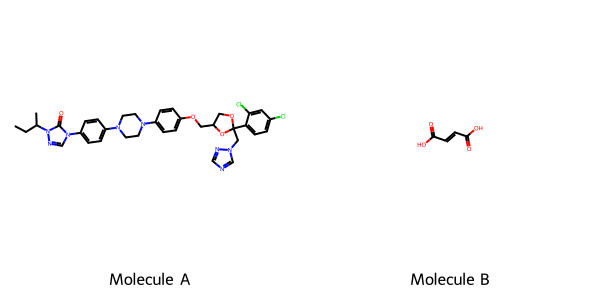

Label: 1 (Сокристалл образуется)


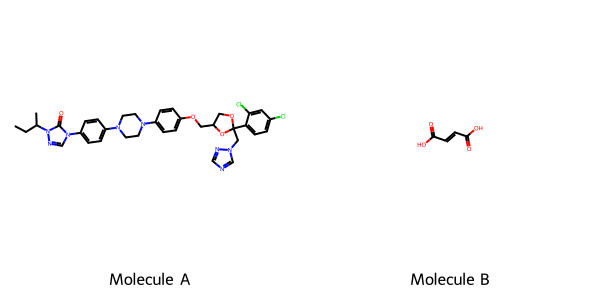

In [6]:
def plot_molecule_pair(smiles1, smiles2, label):
    mol1 = Chem.MolFromSmiles(smiles1)
    mol2 = Chem.MolFromSmiles(smiles2)

    if mol1 and mol2:
        img = Draw.MolsToGridImage([mol1, mol2], molsPerRow=2,
                                   subImgSize=(300, 300),
                                   legends=["Molecule A", "Molecule B"])
        print(f"Label: {label} ({'Сокристалл образуется' if label==1 else 'Не образуется'})")
        display(img)
    else:
        print("Ошибка в SMILES строке")

sample_row = df_train.iloc[0]
plot_molecule_pair(sample_row['SMILES1'], sample_row['SMILES2'], sample_row['result'])
sample_row = df_train.iloc[0]
plot_molecule_pair(sample_row['SMILES1'], sample_row['SMILES2'], sample_row['result'])

In [7]:
smiles_stats1 = df_train["SMILES1"].str.len().describe()
smiles_stats2 = df_train["SMILES2"].str.len().describe()

smiles_stats_test1 = df_test["SMILES1"].str.len().describe()
smiles_stats_test2 = df_test["SMILES2"].str.len().describe()

stats_train_df = pd.DataFrame({
    "stats_slimes1_train":smiles_stats1,
    "stats_slimes2_train": smiles_stats2,
})
stats_test_df = pd.DataFrame({
    "stats_slimes1_test":smiles_stats_test2,
    "stats_slimes2_test": smiles_stats_test2,
})
print(stats_train_df)
print(stats_test_df)

       stats_slimes1_train  stats_slimes2_train
count         16328.000000         16328.000000
mean             30.564735            24.612996
std              25.653134            19.929996
min               1.000000             2.000000
25%              17.000000            15.000000
50%              23.000000            20.000000
75%              36.000000            28.000000
max             440.000000           416.000000
       stats_slimes1_test  stats_slimes2_test
count         1000.000000         1000.000000
mean            29.063000           29.063000
std             22.407747           22.407747
min              4.000000            4.000000
25%             17.000000           17.000000
50%             24.000000           24.000000
75%             36.000000           36.000000
max            307.000000          307.000000


In [8]:
def components(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    desc = [
        Descriptors.MolLogP(mol),                # Коэффициент распределения октанол/вода
        Descriptors.MolWt(mol),                   # Молекулярная масса
        Descriptors.NumHDonors(mol),              # Число доноров водородной связи
        Descriptors.NumHAcceptors(mol),           # Число акцепторов водородной связи
        Descriptors.TPSA(mol),                    # Топологическая полярная поверхность
        Descriptors.NumRotatableBonds(mol),       # Число вращающихся связей
        Descriptors.RingCount(mol),               # Общее число колец
        Descriptors.HeavyAtomCount(mol),          # Число тяжелых атомов
        Descriptors.NHOHCount(mol),                # Число групп NH и OH
        Descriptors.NOCount(mol),                  # Число атомов N и O
        Descriptors.NumValenceElectrons(mol),      # Число валентных электронов
        Descriptors.MaxPartialCharge(mol),         # Максимальный парциальный заряд
        Descriptors.MinPartialCharge(mol),         # Минимальный парциальный заряд
    ]
    return desc

In [9]:
def gen_fingetprints(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024)
    fp=list(fp)
    maccs = MACCSkeys.GenMACCSKeys(mol)
    maccs = list(maccs)
    return fp+maccs

In [10]:
def unite_params(smiles1, smiles2):
    desc1 = components(smiles1)
    desc2 = components(smiles2)
    fp1 = gen_fingetprints(smiles1)
    fp2 = gen_fingetprints(smiles2)
    if desc1 is None or desc2 is None or fp1 is None or fp2 is None:
        return None
    diff = [desc2[i] - desc2[i] for i in range(len(desc1))]
    
    features = desc1 + desc2 + fp1 + fp2 + diff
    return features



In [12]:

def build_dataset(df, has_target=True):
    X = []
    y = []
    for idx, row in tqdm(df.iterrows(), total=len(df), desc='Processing'):
        feat = unite_params(row['SMILES1'], row['SMILES2'])
        if feat is not None:
            X.append(feat)
            if has_target:
                y.append(row['result'])
    X = np.array(X)
    if has_target:
        y = np.array(y)
        return X, y
    else:
        return X

print("processing train...")
X_train, y_train = build_dataset(df_train)
print("processing test...")
X_test = build_dataset(df_test, has_target=False)

print(f"train shape {X_train.shape}, test shape {X_test.shape}")

Processing train...


Processing:   0%|          | 0/16328 [00:00<?, ?it/s][16:13:39] DEPRECATION WARNING: please use MorganGenerator
[16:13:39] DEPRECATION WARNING: please use MorganGenerator
[16:13:39] DEPRECATION WARNING: please use MorganGenerator
[16:13:39] DEPRECATION WARNING: please use MorganGenerator
[16:13:39] DEPRECATION WARNING: please use MorganGenerator
[16:13:39] DEPRECATION WARNING: please use MorganGenerator
[16:13:39] DEPRECATION WARNING: please use MorganGenerator
[16:13:39] DEPRECATION WARNING: please use MorganGenerator
[16:13:39] DEPRECATION WARNING: please use MorganGenerator
[16:13:39] DEPRECATION WARNING: please use MorganGenerator
[16:13:39] DEPRECATION WARNING: please use MorganGenerator
[16:13:39] DEPRECATION WARNING: please use MorganGenerator
[16:13:39] DEPRECATION WARNING: please use MorganGenerator
[16:13:39] DEPRECATION WARNING: please use MorganGenerator
[16:13:39] DEPRECATION WARNING: please use MorganGenerator
[16:13:39] DEPRECATION WARNING: please use MorganGenerator
[16

Processing test...


Processing:   0%|          | 0/1000 [00:00<?, ?it/s][16:15:25] DEPRECATION WARNING: please use MorganGenerator
[16:15:25] DEPRECATION WARNING: please use MorganGenerator
[16:15:25] DEPRECATION WARNING: please use MorganGenerator
[16:15:25] DEPRECATION WARNING: please use MorganGenerator
[16:15:25] DEPRECATION WARNING: please use MorganGenerator
[16:15:25] DEPRECATION WARNING: please use MorganGenerator
[16:15:25] DEPRECATION WARNING: please use MorganGenerator
[16:15:25] DEPRECATION WARNING: please use MorganGenerator
[16:15:25] DEPRECATION WARNING: please use MorganGenerator
[16:15:25] DEPRECATION WARNING: please use MorganGenerator
[16:15:25] DEPRECATION WARNING: please use MorganGenerator
[16:15:25] DEPRECATION WARNING: please use MorganGenerator
[16:15:26] DEPRECATION WARNING: please use MorganGenerator
[16:15:26] DEPRECATION WARNING: please use MorganGenerator
[16:15:26] DEPRECATION WARNING: please use MorganGenerator
[16:15:26] DEPRECATION WARNING: please use MorganGenerator
[16:

Train shape: (16328, 2421), Test shape: (1000, 2421)


In [ ]:
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)
neg = (y_tr == 0).sum()
pos = (y_tr == 1).sum()
scale_pos_weight = neg / pos
print(f"scale_pos_weight = {scale_pos_weight:.3f}")

scale_pos_weight = 0.129


In [ ]:
model = xgb.XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    n_estimators=200,
    max_depth=6,
    learning_rate=0.9,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=20
)

model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False
)
preds = model.predict_proba(X_test)[:, 1]
submission = pd.DataFrame({
    'id': df_test['id'],
    'result': (preds > 0.5).astype(int)
})
submission.to_csv('submission4.csv', index=False)
print("Submission saved.")

C:\Users\sypna\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\callback.py:385: UserWarning: [18:02:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


Submission saved.
